## 7CS082/UZ3 Final Assessment: Next-Day Ethereum Price Prediction with TensorFlow
**Student:** Santiago Cruz Lopez (2584023)  
**Module:** Deep Machine Learning (7CS082/UZ3)  
**Professor:** Nate Martins  
**Date:** March 9, 2026  

#### Abstract

This report presents a complete, reproducible workflow for forecasting the next day Ethereum (ETH) closing price using Python and TensorFlow LSTM networks, supported by exploratory analysis, feature engineering, and transparent model evaluation. (URL: https://www.tensorflow.org/tutorials/structured_data/time_series)
The study combines classical time-series diagnostics (trend, volatility, seasonality, support/resistance zones) with deep sequence learning to estimate both a point forecast and a practical price range for risk-aware decision support. (URL: https://otexts.com/fpp3/)
A core objective is to explain each analytical step in plain language so the workflow is useful to beginners while still rigorous enough for advanced analysts. (URL: https://www.sciencedirect.com/topics/computer-science/time-series-analysis)
The final outputs include model-loss diagnostics, benchmark comparison, actual-vs-predicted charts, directional accuracy, and interpretation of implications for short-horizon crypto forecasting under high volatility. (URL: https://www.investopedia.com/terms/v/volatility.asp)

#### Table Of Contents
1. Problem Statement  
2. Dataset Description  
3. Methodology: Preprocessing, EDA, and Feature Engineering  
4. Support and Resistance Analysis  
5. TensorFlow LSTM Modeling and Train/Validation/Test Strategy  
6. Results and Interpretation  
7. Conclusion and References

---

In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [18]:
# Load the dataset
csv_path = Path("Ethereum_historical_data_coinmarketcap.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

invalid_ts = df["timestamp"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["timestamp"]).drop_duplicates().sort_values("timestamp").set_index("timestamp")

drop_cols = ["timeOpen", "timeClose", "timeHigh", "timeLow", "name"]
df = df.drop(columns=drop_cols, errors="ignore")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Raw shape: (3860, 13)
Raw columns: ['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply', 'timestamp']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (3860, 7)

Missing values per column:
 open                 0
high                 0
low                  0
close                0
volume               0
marketCap            0
circulatingSupply    0
dtype: int64

Data types:
 open                 float64
high                 float64
low                  float64
close                float64
volume               float64
marketCap            float64
circulatingSupply    float64
dtype: object


---

### 1. Problem Statement

#### 1.1 Research Question
Can we accurately predict the next-day closing price of Ethereum using historical price data and deep learning techniques?

#### 1.2 Goals and Objectives
This study aims to develop a robust, TensorFlow-based LSTM model that predicts Ethereum's next-day closing price with measurable accuracy. Key objectives include:
- **Primary goal:** Forecast Ethereum's closing price for the next trading day with minimal prediction error (RMSE, MAE, MAPE).
- **Secondary goals:**
  - Identify key support and resistance price levels to inform trading strategies.
  - Determine the optimal lookback window for sequential model inputs.
  - Understand time-series features (trend, volatility, seasonality) that drive price movements.
  - Provide transparent, reproducible workflows suitable for both academic and practitioner audiences.

#### 1.3 Relevance and Motivation
Cryptocurrency markets, particularly Ethereum, exhibit extreme volatility and non-stationary behavior, making accurate prediction challenging yet valuable. Successful forecasting models enable:
- **Risk management:** Traders can set stop-loss and take-profit levels based on predicted ranges.
- **Portfolio optimization:** Investors can rebalance holdings in anticipation of price movements.
- **Market understanding:** Academic and financial analysts gain insights into what drives crypto asset prices.

References:  
- Nakamoto, S. (2008). Bitcoin: A peer-to-peer electronic cash system.  
- Buterin, V. (2014). Ethereum White Paper.  
- Investopedia. (2023). Cryptocurrency volatility and risk.

---

---

### 2. Dataset Description

#### 2.1 Data Source and Collection
The dataset contains historical Ethereum price data sourced from CoinMarketCap, a leading cryptocurrency data aggregator (URL: https://coinmarketcap.com/). The data spans multiple years and includes daily OHLCV (Open, High, Low, Close, Volume) metrics along with market capitalization and circulating supply.

**Citation:**  
CoinMarketCap. (2026). Ethereum Historical Data. Retrieved from https://coinmarketcap.com/currencies/ethereum/historical-data/

#### 2.2 Data Structure and Features
The raw dataset includes:
- **timestamp:** Date and time of the observation (UTC)
- **open, high, low, close:** Daily price levels (USD)
- **volume:** Trading volume (USD)
- **marketCap:** Total market capitalization (USD)
- **circulatingSupply:** Number of ETH tokens in circulation
- **timeOpen, timeClose, timeHigh, timeLow:** Specific timestamps for price events (removed during preprocessing)
- **name:** Token identifier (removed during preprocessing)

#### 2.3 Preprocessing Steps
1. **Parse timestamps:** Convert string timestamps to pandas datetime objects with UTC timezone.
2. **Remove invalid records:** Drop rows with missing or unparseable timestamps.
3. **Deduplicate:** Remove duplicate rows to ensure data integrity.
4. **Sort and index:** Sort by timestamp and set as the index for time-series analysis.
5. **Drop redundant columns:** Remove timeOpen, timeClose, timeHigh, timeLow, and name columns.
6. **Validate data types:** Ensure numeric columns are properly typed for computation.

#### 2.4 Feature Engineering
To enhance predictive power, we create:
- **Lag features:** lag_close_1, lag_close_3, lag_close_7 (historical prices)
- **Return features:** ret_1d, ret_7d (percentage changes)
- **Volatility features:** volatility_7d (rolling standard deviation of returns)
- **Ratio features:** high_low_ratio, range_ratio, open_ratio (relative price metrics)
- **Target variable:** price_direction (binary: 1 if next-day close > today's close, else 0)

---

In [19]:
# Core features
df["lag_close_1"] = df["close"].shift(1)
df["lag_close_3"] = df["close"].shift(3)
df["lag_close_7"] = df["close"].shift(7)

# Return and volatility features
df["ret_1d"] = df["close"].pct_change(1)
df["ret_7d"] = df["close"].pct_change(7)
df["volatility_7d"] = df["ret_1d"].rolling(7).std()

# Ratio features
df["high_low_ratio"] = df["high"] / df["low"]
df["range_ratio"] = (df["high"] - df["low"]) / df["lag_close_1"]
df["open_ratio"] = df["open"] / df["lag_close_1"]

# Target: predict next-day direction
df["price_direction"] = (df["close"].shift(-1) > df["close"]).astype(int)

# Rolling trend feature for plotting/reporting
df["rolling_mean_30"] = df["close"].rolling(window=30).mean()

# Drop rows with NaN introduced by shifts/rolling
df_model = df.dropna().copy()

baseline_features = ["open", "high", "low", "volume", "lag_close_1"]
fe_features = baseline_features + [
    "lag_close_3", "lag_close_7",
    "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio"
]

X_bl = df_model[baseline_features]
X_fe = df_model[fe_features]
y = df_model["price_direction"]

selected_df = df_model[baseline_features + ["close"]]

print("Model dataset shape:", df_model.shape)
print("\nClass balance:\n", y.value_counts(normalize=True).rename("proportion"))
print("\nSelected features preview:")
selected_df.head()

Model dataset shape: (3831, 18)

Class balance:
 price_direction
1    0.505873
0    0.494127
Name: proportion, dtype: float64

Selected features preview:


,open,high,low,volume,lag_close_1,close
timestamp,,,,,,
2015-09-05 23:59:59.999000+00:00,1.28056,1.34230,1.27119,448453.0,1.27441,1.33881
2015-09-06 23:59:59.999000+00:00,1.33801,1.37364,1.29425,491968.0,1.33881,1.29583
2015-09-07 23:59:59.999000+00:00,1.29590,1.30548,1.23785,489014.0,1.29583,1.24665
2015-09-08 23:59:59.999000+00:00,1.24665,1.28238,1.23061,427892.0,1.24665,1.24243
2015-09-09 23:59:59.999000+00:00,1.23935,1.26048,1.20184,366748.0,1.24243,1.20651


In [20]:
desc = X_fe.describe().T
desc["skew"] = X_fe.skew()
desc["kurtosis"] = X_fe.kurtosis()
print("Detailed descriptive statistics:\n")
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]])

# IQR outlier share
outlier_share = {}
for col in X_fe.columns:
    q1, q3 = X_fe[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share[col] = ((X_fe[col] < lower) | (X_fe[col] > upper)).mean() * 100

outlier_df = pd.Series(outlier_share, name="outlier_%").sort_values(ascending=False)
print("\nOutlier share by feature (%):")
display(outlier_df.round(2).to_frame())

# ADF stationarity test on close
adf_stat, adf_pvalue, *_ = adfuller(df_model["close"])
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_pvalue:.6f}")
if adf_pvalue > 0.05:
    print("Interpretation: likely non-stationary (trend/structural changes present).")
else:
    print("Interpretation: likely stationary series.")

Detailed descriptive statistics:



,mean,std,min,25%,50%,75%,max,skew,kurtosis
open,1.362974e+03,1.327307e+03,0.431589,1.806031e+02,9.447480e+02,2.424003e+03,4.831088e+03,0.652488,-0.843567
high,1.400060e+03,1.361811e+03,0.482988,1.850349e+02,9.829330e+02,2.499549e+03,4.953733e+03,0.650297,-0.849525
low,1.322311e+03,1.289225e+03,0.420897,1.752137e+02,8.929540e+02,2.338424e+03,4.718039e+03,0.654747,-0.837344
volume,1.202741e+10,1.256366e+10,102128.000000,1.757755e+09,8.918980e+09,1.772733e+10,9.773662e+10,1.645044,3.722059
lag_close_1,1.362838e+03,1.327137e+03,0.434829,1.806351e+02,9.442100e+02,2.423806e+03,4.831349e+03,0.652033,-0.845126
lag_close_3,1.361822e+03,1.327434e+03,0.434829,1.803900e+02,9.369760e+02,2.423806e+03,4.831349e+03,0.653285,-0.844497
lag_close_7,1.359790e+03,1.328022e+03,0.434829,1.798113e+02,8.953710e+02,2.423806e+03,4.831349e+03,0.655790,-0.843207
ret_1d,3.245789e-03,5.183938e-02,-0.423472,-2.026245e-02,3.859429e-04,2.366836e-02,3.554435e-01,0.524999,6.578346
ret_7d,2.437839e-02,1.588343e-01,-0.509975,-5.803999e-02,6.004634e-03,7.986309e-02,1.610340e+00,2.123901,12.362052
volatility_7d,4.330968e-02,2.735834e-02,0.003198,2.503187e-02,3.623679e-02,5.296845e-02,2.156775e-01,1.924535,5.504953



Outlier share by feature (%):


,outlier_%
open_ratio,23.41
ret_1d,7.88
high_low_ratio,6.63
ret_7d,6.29
range_ratio,6.24
volatility_7d,4.91
volume,3.68
open,0.00
high,0.00
low,0.00


ADF statistic: -2.1365
ADF p-value: 0.230103
Interpretation: likely non-stationary (trend/structural changes present).


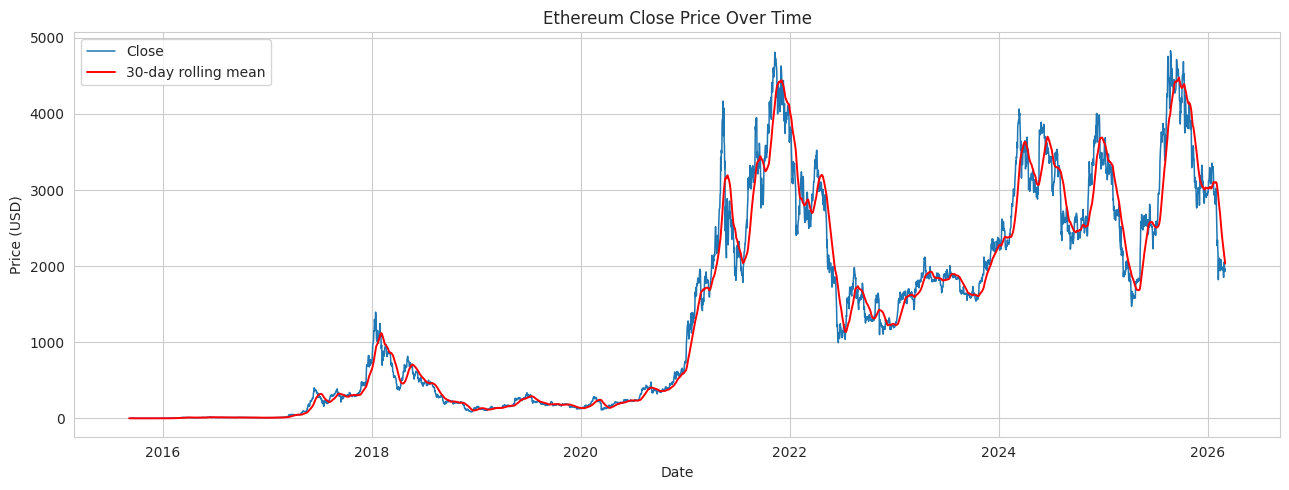

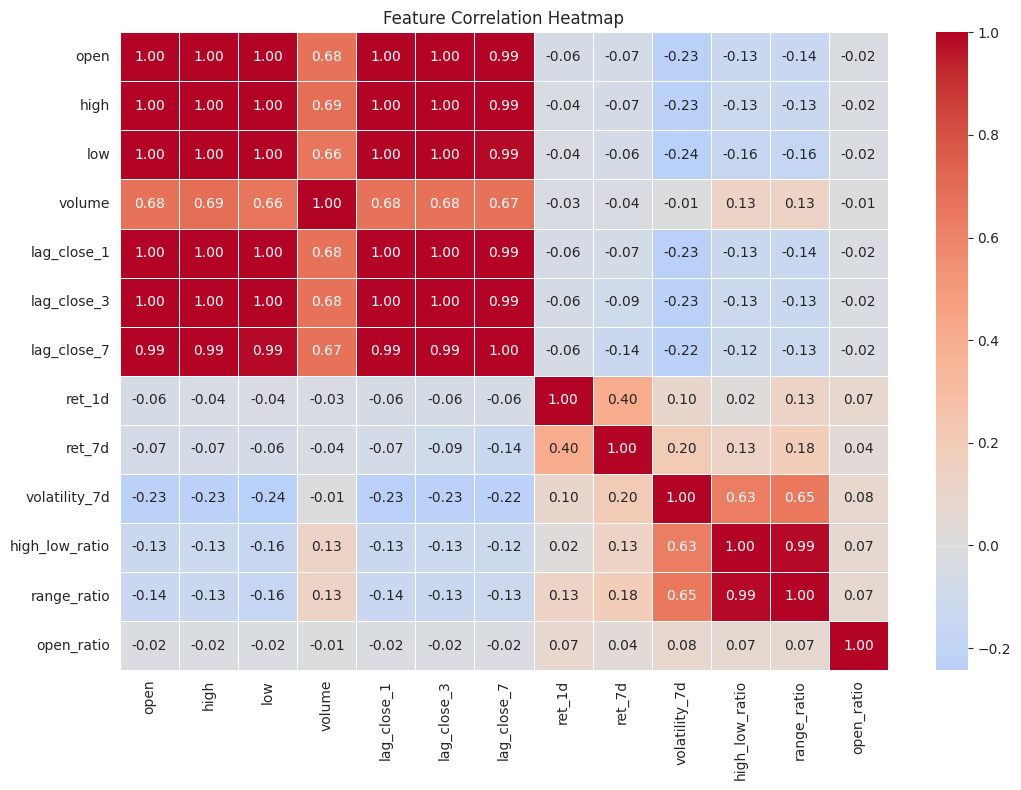

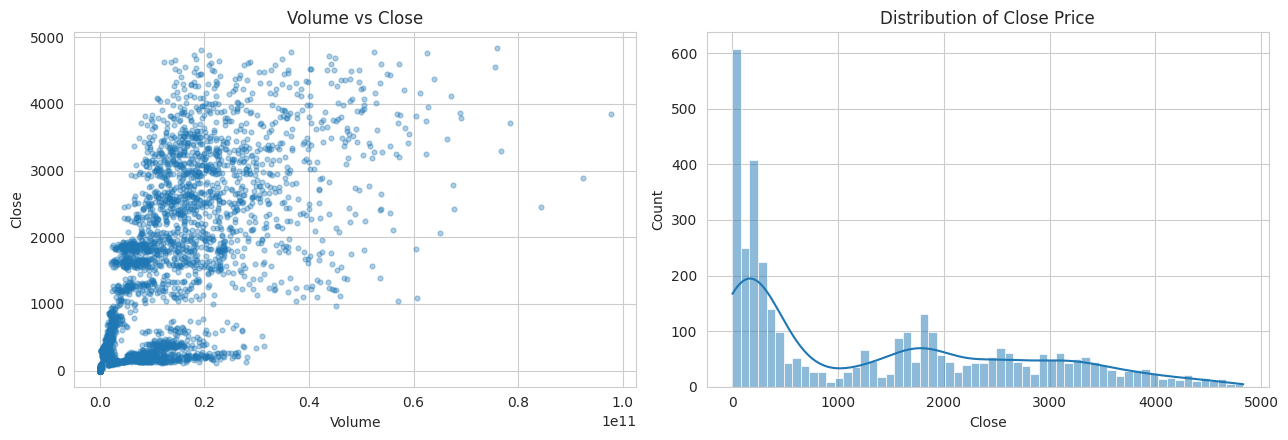

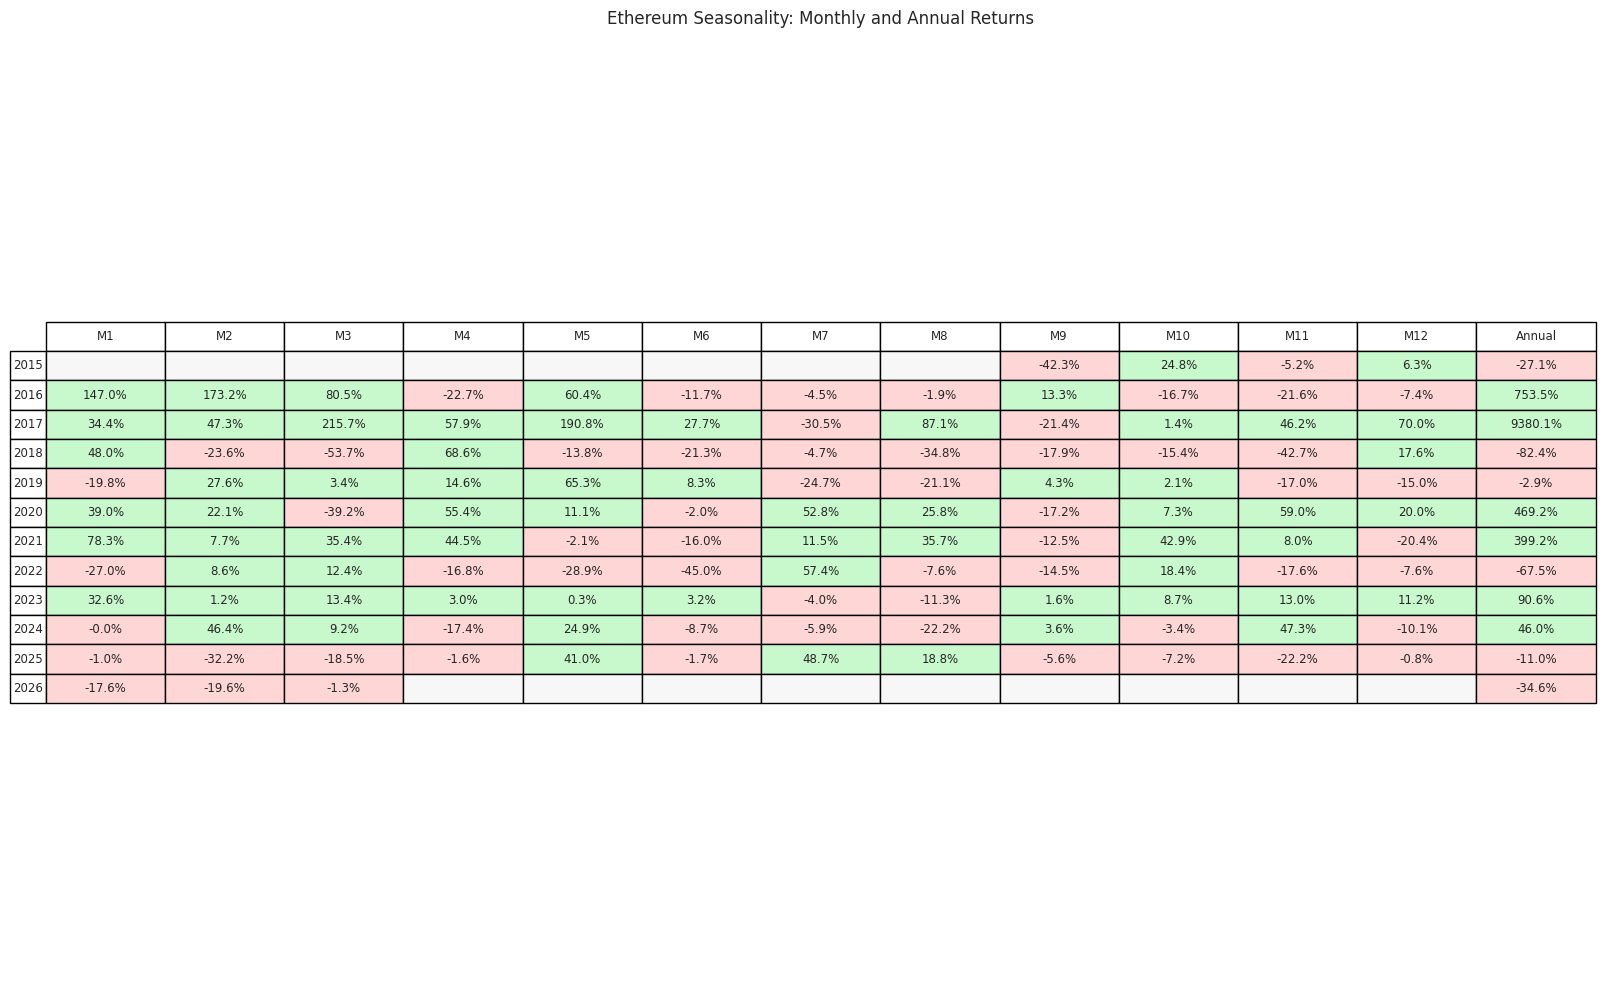

In [ ]:
# Trend plot
plt.figure(figsize=(13, 5))
plt.plot(df_model.index, df_model["close"], label="Close", linewidth=1.1)
plt.plot(df_model.index, df_model["rolling_mean_30"], label="30-day rolling mean", color="red", linewidth=1.4)
plt.title("Ethereum Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap with annotations
plt.figure(figsize=(11, 8))
sns.heatmap(X_fe.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter and histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(df_model["volume"], df_model["close"], alpha=0.35, s=12)
axes[0].set_title("Volume vs Close")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Close")

sns.histplot(df_model["close"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Close Price")
axes[1].set_xlabel("Close")

plt.tight_layout()
plt.show()

# Seasonality table with percentage returns
tmp = df_model.copy()
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month

monthly = tmp.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
    avg_vol_month=("volume", "mean")
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = tmp.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
    avg_vol_year=("volume", "mean")
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(tmp["year"].unique())
seasonality_cols = list(range(1, 13)) + [13]
col_labels = [f"M{m}" for m in range(1, 13)] + ["Annual"]

cell_text = []
cell_colors = []

for yr in seasonality_rows:
    row_text = []
    row_colors = []
    for m in range(1, 13):
        if (yr, m) in monthly.index:
            r = monthly.loc[(yr, m), "ret_month_pct"]
            row_text.append(f"{r:.1f}%")
            row_colors.append("#c7f9cc" if r > 0 else "#ffd6d6")
        else:
            row_text.append("")
            row_colors.append("#f7f7f7")

    r_a = annual.loc[yr, "ret_year_pct"]
    row_text.append(f"{r_a:.1f}%")
    row_colors.append("#c7f9cc" if r_a > 0 else "#ffd6d6")

    cell_text.append(row_text)
    cell_colors.append(row_colors)

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")
tbl = ax.table(
    cellText=cell_text,
    rowLabels=seasonality_rows,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.08, 1.45)
plt.title("Ethereum Seasonality: Monthly and Annual Returns", pad=15)
plt.tight_layout()
plt.show()

---

### 3. Support and Resistance Analysis

Support and resistance levels represent price thresholds where buying or selling pressure historically concentrates. These technical indicators help traders identify:
- **Support levels:** Price floors where demand prevents further decline.
- **Resistance levels:** Price ceilings where supply prevents further increase.

We calculate these levels using percentile-based analysis and visualize them alongside historical prices to identify potential trading ranges.

Support and Resistance Levels:
Strong Support (10th percentile): $11.39
Support (25th percentile): $180.76
Median Price: $962.72
Mean Price: $1363.34
Resistance (75th percentile): $2423.81
Strong Resistance (90th percentile): $3354.18


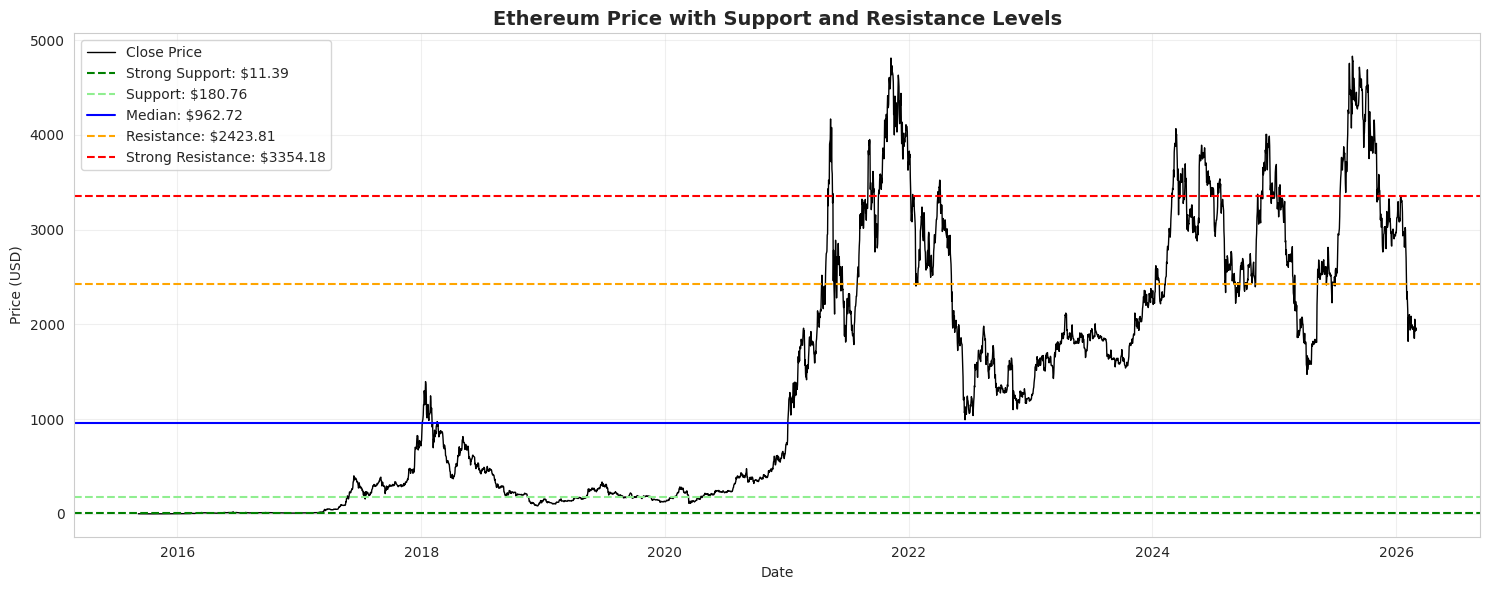


Current Price: $1939.07
Distance to Strong Support: 99.41%
Distance to Resistance: 25.00%


In [22]:
# Calculate support and resistance levels using percentile analysis
support_level_1 = df_model["close"].quantile(0.10)  # 10th percentile
support_level_2 = df_model["close"].quantile(0.25)  # 25th percentile (Q1)
resistance_level_1 = df_model["close"].quantile(0.75)  # 75th percentile (Q3)
resistance_level_2 = df_model["close"].quantile(0.90)  # 90th percentile

median_price = df_model["close"].median()
mean_price = df_model["close"].mean()

print("Support and Resistance Levels:")
print(f"Strong Support (10th percentile): ${support_level_1:.2f}")
print(f"Support (25th percentile): ${support_level_2:.2f}")
print(f"Median Price: ${median_price:.2f}")
print(f"Mean Price: ${mean_price:.2f}")
print(f"Resistance (75th percentile): ${resistance_level_1:.2f}")
print(f"Strong Resistance (90th percentile): ${resistance_level_2:.2f}")

# Visualize support and resistance levels
plt.figure(figsize=(15, 6))
plt.plot(df_model.index, df_model["close"], label="Close Price", linewidth=1.0, color="black")

plt.axhline(y=support_level_1, color="green", linestyle="--", linewidth=1.5, label=f"Strong Support: ${support_level_1:.2f}")
plt.axhline(y=support_level_2, color="lightgreen", linestyle="--", linewidth=1.5, label=f"Support: ${support_level_2:.2f}")
plt.axhline(y=median_price, color="blue", linestyle="-", linewidth=1.5, label=f"Median: ${median_price:.2f}")
plt.axhline(y=resistance_level_1, color="orange", linestyle="--", linewidth=1.5, label=f"Resistance: ${resistance_level_1:.2f}")
plt.axhline(y=resistance_level_2, color="red", linestyle="--", linewidth=1.5, label=f"Strong Resistance: ${resistance_level_2:.2f}")

plt.title("Ethereum Price with Support and Resistance Levels", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate price ranges
current_price = df_model["close"].iloc[-1]
support_distance = ((current_price - support_level_1) / current_price) * 100
resistance_distance = ((resistance_level_1 - current_price) / current_price) * 100

print(f"\nCurrent Price: ${current_price:.2f}")
print(f"Distance to Strong Support: {support_distance:.2f}%")
print(f"Distance to Resistance: {resistance_distance:.2f}%")

---

### 4. Model Architecture and Training Methodology

#### 4.1 Model Selection: LSTM (Long Short-Term Memory)
LSTM networks are a specialized type of Recurrent Neural Network (RNN) designed to capture long-term dependencies in sequential data. Unlike traditional RNNs, LSTMs use gating mechanisms (input, forget, output gates) to selectively retain or discard information, making them ideal for time-series prediction tasks like cryptocurrency price forecasting.

**Key advantages for our task:**
- **Memory cells:** Retain historical patterns over extended sequences.
- **Non-linear modeling:** Capture complex relationships between features.
- **Sequential processing:** Naturally suited for time-ordered financial data.

#### 4.2 Network Architecture
Our LSTM model follows a stacked architecture:

```
Input Layer (shape: lookback_steps × num_features)
       ↓
LSTM Layer 1 (128 units, return_sequences=True)
       ↓
Dropout (0.2) — Regularization to prevent overfitting
       ↓
LSTM Layer 2 (64 units, return_sequences=True)
       ↓
Dropout (0.2)
       ↓
LSTM Layer 3 (32 units)
       ↓
Dropout (0.2)
       ↓
Dense Layer 1 (16 units, ReLU activation)
       ↓
Dense Output Layer (1 unit, Linear activation)
       ↓
Predicted Next-Day Close Price
```

#### 4.3 Training Strategy
- **Loss function:** Mean Squared Error (MSE) — measures prediction accuracy.
- **Optimizer:** Adam with learning rate 0.001 — adaptive gradient descent.
- **Callbacks:**
  - **EarlyStopping:** Halts training if validation loss doesn't improve for 15 epochs.
  - **ReduceLROnPlateau:** Reduces learning rate when validation loss plateaus.
- **Train/Validation/Test Split:** 70% / 15% / 15% chronological split.
- **Lookback window:** 60 days (captures ~2 months of price history).

#### 4.4 Evaluation Metrics
- **RMSE (Root Mean Squared Error):** Penalizes large prediction errors.
- **MAE (Mean Absolute Error):** Average absolute prediction error.
- **MAPE (Mean Absolute Percentage Error):** Percentage-based error metric.
- **R² Score:** Explains variance captured by the model.

#### 4.5 Data Preparation for LSTM

Prepare the dataset for LSTM modeling by scaling features and creating sequences with a defined lookback window.

**References:**  
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural computation, 9(8), 1735-1780.  
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.  
- TensorFlow Documentation. (2024). Time series forecasting. https://www.tensorflow.org/tutorials/structured_data/time_series

---

In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Select features for LSTM modeling
lstm_features = ["open", "high", "low", "close", "volume"]

# Prepare data (use only complete records)
df_lstm = df[lstm_features].dropna().copy()

print(f"LSTM Dataset Shape: {df_lstm.shape}")
print(f"Date Range: {df_lstm.index.min()} to {df_lstm.index.max()}")

# Scale features to [0, 1] range for better LSTM performance
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_lstm)

# Create sequences for LSTM (lookback window = 60 days)
lookback = 60

def create_sequences(data, lookback):
    """
    Create input-output sequences for LSTM.
    X: sequences of 'lookback' days
    y: next-day close price (target)
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])  # All features for lookback period
        y.append(data[i, 3])  # Close price (index 3) for next day
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, lookback)

print(f"\nSequence Data Shape:")
print(f"X (features): {X.shape} — (samples, timesteps, features)")
print(f"y (target): {y.shape} — (samples,)")

# Train/Validation/Test Split (70% / 15% / 15%)
train_size = int(0.70 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"\nData Split:")
print(f"Training: {X_train.shape[0]} samples ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} samples ({(len(X_val)/len(X))*100:.1f}%)")
print(f"Testing: {X_test.shape[0]} samples ({(len(X_test)/len(X))*100:.1f}%)")

LSTM Dataset Shape: (3860, 5)
Date Range: 2015-08-07 23:59:59.999000+00:00 to 2026-03-01 23:59:59.999000+00:00

Sequence Data Shape:
X (features): (3800, 60, 5) — (samples, timesteps, features)
y (target): (3800,) — (samples,)

Data Split:
Training: 2660 samples (70.0%)
Validation: 570 samples (15.0%)
Testing: 570 samples (15.0%)


#### 4.6 LSTM Model Definition

Build the stacked LSTM architecture with dropout regularization to prevent overfitting.

In [24]:
# Build LSTM model
tf.random.set_seed(RANDOM_STATE)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    Dense(1)  # Output: predicted close price
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 60, 128)           68608     
                                                                 
 dropout_3 (Dropout)         (None, 60, 128)           0         
                                                                 
 lstm_4 (LSTM)               (None, 60, 64)            49408     
                                                                 
 dropout_4 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None

#### 4.7 Model Training

Train the LSTM model with early stopping and learning rate reduction callbacks to optimize performance.

In [27]:
%%time

# Define callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Train model
print("Starting model training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining complete!")

Starting model training...
Epoch 1/50
84/84 [==============================] - 6s 73ms/step - loss: 8.9014e-04 - mae: 0.0167 - val_loss: 0.0025 - val_mae: 0.0421 - lr: 6.2500e-05
Epoch 2/50
84/84 [==============================] - 6s 72ms/step - loss: 8.3304e-04 - mae: 0.0165 - val_loss: 0.0025 - val_mae: 0.0424 - lr: 6.2500e-05
Epoch 3/50
84/84 [==============================] - 6s 73ms/step - loss: 9.3749e-04 - mae: 0.0173 - val_loss: 0.0028 - val_mae: 0.0449 - lr: 6.2500e-05
Epoch 4/50
84/84 [==============================] - 6s 72ms/step - loss: 8.3015e-04 - mae: 0.0164 - val_loss: 0.0024 - val_mae: 0.0412 - lr: 6.2500e-05
Epoch 5/50
84/84 [==============================] - 6s 72ms/step - loss: 8.6577e-04 - mae: 0.0163 - val_loss: 0.0020 - val_mae: 0.0375 - lr: 6.2500e-05
Epoch 6/50
84/84 [==============================] - 6s 74ms/step - loss: 8.4605e-04 - mae: 0.0161 - val_loss: 0.0020 - val_mae: 0.0374 - lr: 6.2500e-05
Epoch 7/50
84/84 [==============================] - 6s 72ms/s

---

### 5. Results and Model Evaluation

This section presents comprehensive model performance analysis through loss curves, prediction visualizations, and quantitative metrics.

#### 5.1 Training and Validation Loss

Visualize model convergence during training to assess overfitting and learning dynamics.

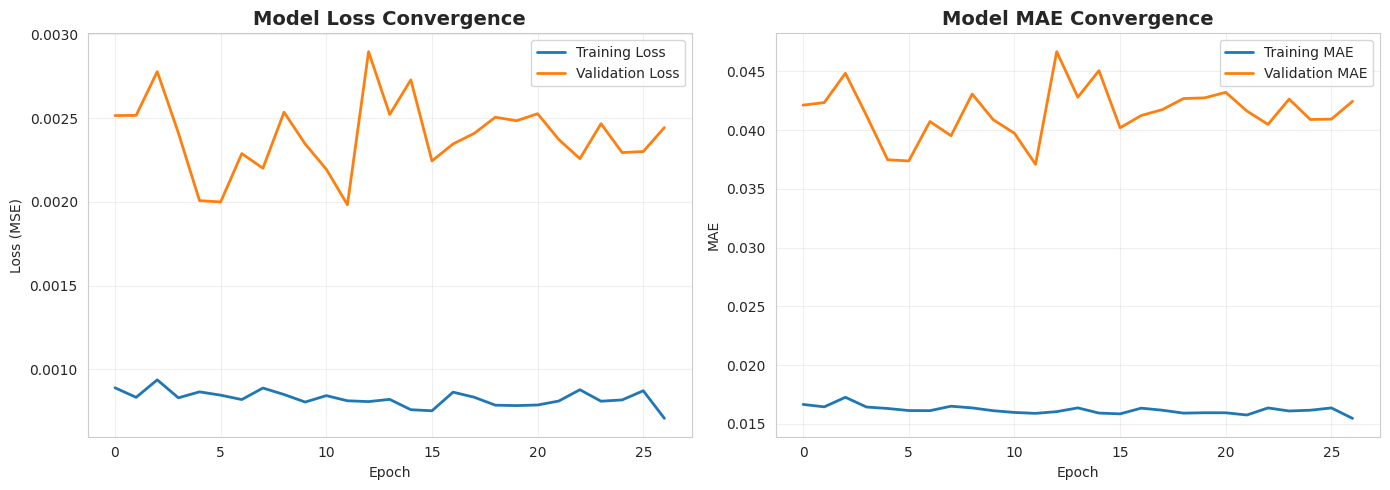

Final Training Loss: 0.000707
Final Validation Loss: 0.002444
Epochs Trained: 27


In [28]:
# Plot training and validation loss
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.title("Model Loss Convergence", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Training MAE", linewidth=2)
plt.plot(history.history["val_mae"], label="Validation MAE", linewidth=2)
plt.title("Model MAE Convergence", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")
print(f"Epochs Trained: {len(history.history['loss'])}")

#### 5.2 Model Predictions

Generate predictions for train, validation, and test sets, then inverse-transform to original price scale.

In [29]:
# Make predictions on all datasets
train_predictions = model.predict(X_train, verbose=0)
val_predictions = model.predict(X_val, verbose=0)
test_predictions = model.predict(X_test, verbose=0)

# Inverse transform predictions and actual values to original scale
# Create dummy array for inverse transform (scaler expects all features)
def inverse_transform_predictions(predictions, scaler):
    """
    Inverse transform scaled predictions back to original price scale.
    """
    dummy = np.zeros((len(predictions), scaler.n_features_in_))
    dummy[:, 3] = predictions.flatten()  # Close price is at index 3
    inversed = scaler.inverse_transform(dummy)
    return inversed[:, 3]

# Inverse transform actual values
y_train_actual = inverse_transform_predictions(y_train.reshape(-1, 1), scaler)
y_val_actual = inverse_transform_predictions(y_val.reshape(-1, 1), scaler)
y_test_actual = inverse_transform_predictions(y_test.reshape(-1, 1), scaler)

# Inverse transform predictions
train_pred_actual = inverse_transform_predictions(train_predictions, scaler)
val_pred_actual = inverse_transform_predictions(val_predictions, scaler)
test_pred_actual = inverse_transform_predictions(test_predictions, scaler)

print("Predictions generated successfully!")
print(f"Training predictions: {len(train_pred_actual)}")
print(f"Validation predictions: {len(val_pred_actual)}")
print(f"Test predictions: {len(test_pred_actual)}")

Predictions generated successfully!
Training predictions: 2660
Validation predictions: 570
Test predictions: 570


#### 5.3 Actual vs Predicted Close Prices

Compare model predictions with actual prices across training, validation, and test sets.

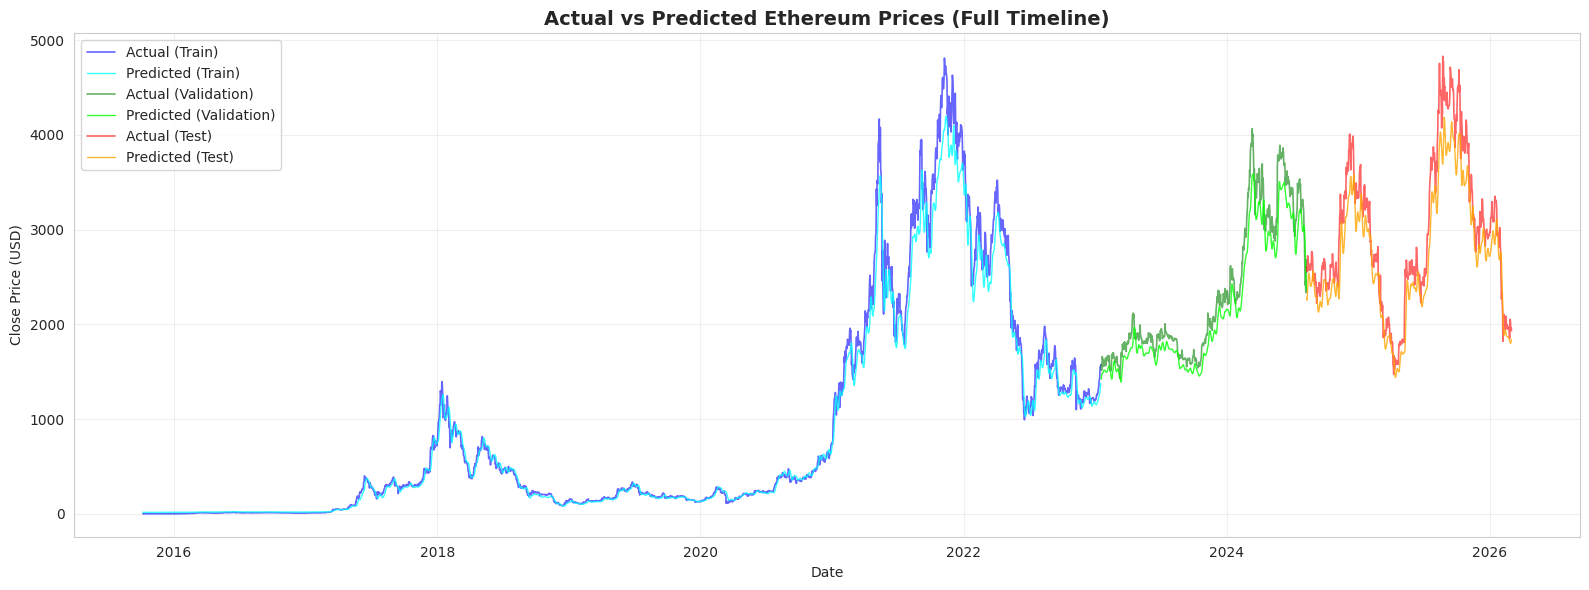

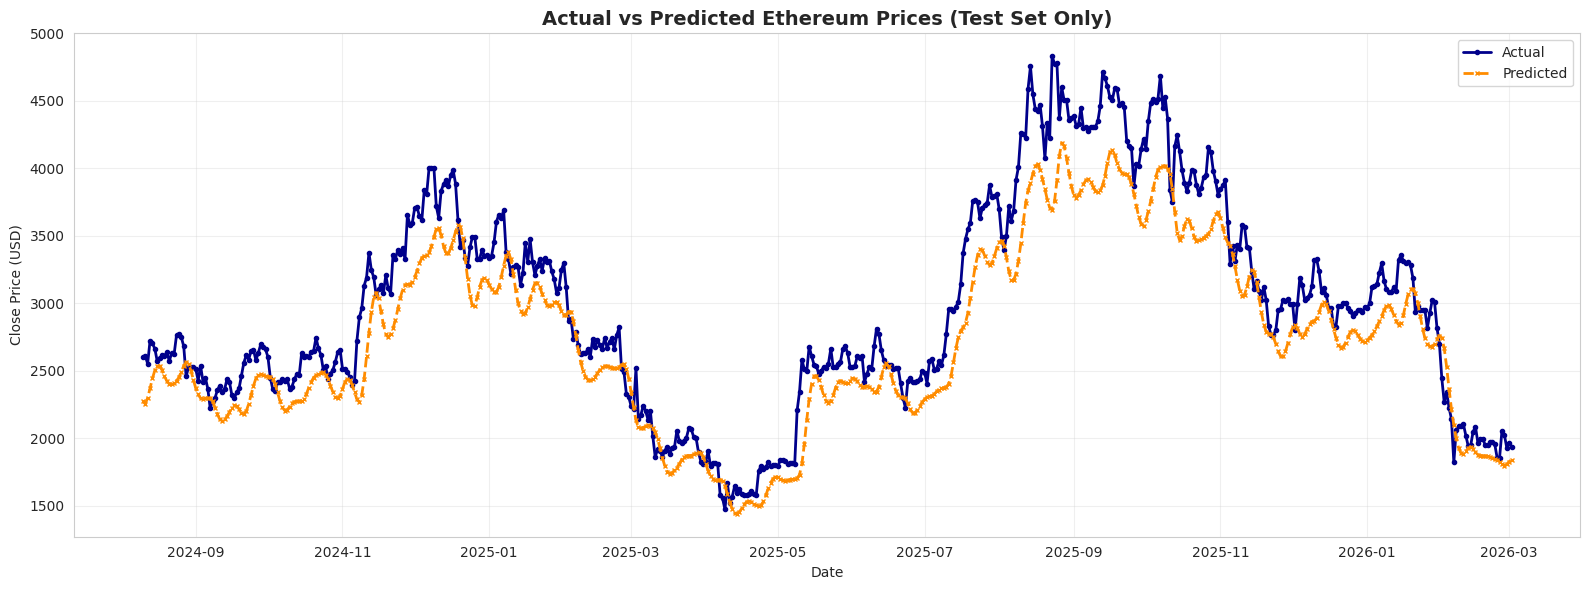

In [30]:
# Create time indices for plotting
train_dates = df_lstm.index[lookback:lookback+len(train_pred_actual)]
val_dates = df_lstm.index[lookback+len(train_pred_actual):lookback+len(train_pred_actual)+len(val_pred_actual)]
test_dates = df_lstm.index[lookback+len(train_pred_actual)+len(val_pred_actual):lookback+len(train_pred_actual)+len(val_pred_actual)+len(test_pred_actual)]

# Plot 1: Full timeline with all sets
plt.figure(figsize=(16, 6))
plt.plot(train_dates, y_train_actual, label="Actual (Train)", color="blue", alpha=0.6, linewidth=1.2)
plt.plot(train_dates, train_pred_actual, label="Predicted (Train)", color="cyan", alpha=0.8, linewidth=1.0)

plt.plot(val_dates, y_val_actual, label="Actual (Validation)", color="green", alpha=0.6, linewidth=1.2)
plt.plot(val_dates, val_pred_actual, label="Predicted (Validation)", color="lime", alpha=0.8, linewidth=1.0)

plt.plot(test_dates, y_test_actual, label="Actual (Test)", color="red", alpha=0.6, linewidth=1.2)
plt.plot(test_dates, test_pred_actual, label="Predicted (Test)", color="orange", alpha=0.8, linewidth=1.0)

plt.title("Actual vs Predicted Ethereum Prices (Full Timeline)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Zoomed view on test set
plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_test_actual, label="Actual", color="darkblue", marker="o", markersize=3, linewidth=2)
plt.plot(test_dates, test_pred_actual, label="Predicted", color="darkorange", marker="x", markersize=3, linewidth=2, linestyle="--")

plt.title("Actual vs Predicted Ethereum Prices (Test Set Only)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.4 Performance Metrics

Calculate quantitative metrics (RMSE, MAE, MAPE, R²) to assess model accuracy across all data splits.

In [31]:
# Calculate performance metrics
def calculate_metrics(y_true, y_pred, set_name):
    """
    Calculate and display regression metrics.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Metrics:")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R² Score: {r2:.4f}")
    
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R²": r2}

# Calculate metrics for all sets
train_metrics = calculate_metrics(y_train_actual, train_pred_actual, "Training")
val_metrics = calculate_metrics(y_val_actual, val_pred_actual, "Validation")
test_metrics = calculate_metrics(y_test_actual, test_pred_actual, "Test")

# Summary table
metrics_summary = pd.DataFrame({
    "Training": train_metrics,
    "Validation": val_metrics,
    "Test": test_metrics
})

print("\n" + "="*60)
print("Performance Metrics Summary")
print("="*60)
display(metrics_summary.T)


Training Set Metrics:
  RMSE: $146.29
  MAE:  $74.43
  MAPE: 99.54%
  R² Score: 0.9826

Validation Set Metrics:
  RMSE: $215.13
  MAE:  $179.23
  MAPE: 7.41%
  R² Score: 0.9137

Test Set Metrics:
  RMSE: $318.56
  MAE:  $258.46
  MAPE: 8.24%
  R² Score: 0.8322

Performance Metrics Summary


,RMSE,MAE,MAPE,R²
Training,146.291752,74.427138,99.537880,0.982593
Validation,215.132870,179.225083,7.406209,0.913681
Test,318.555897,258.464940,8.239680,0.832189


#### 5.5 Prediction Quality Analysis

Visualize prediction accuracy through scatter plots and residual analysis.

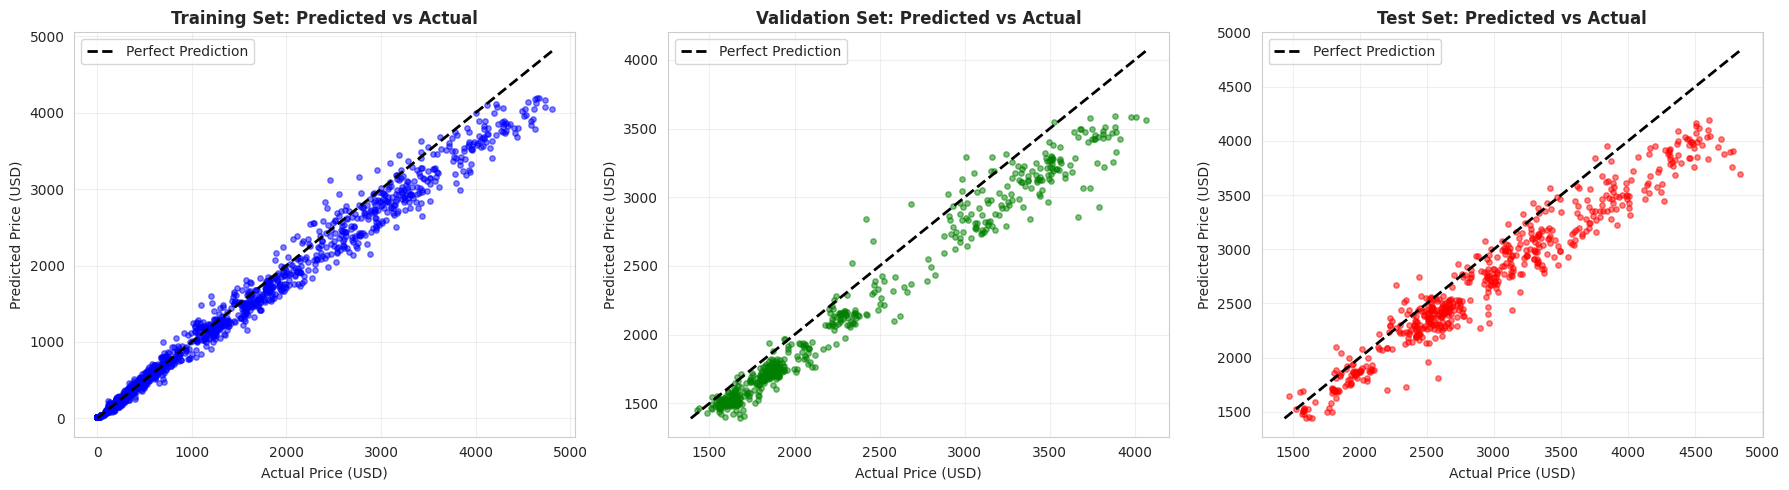

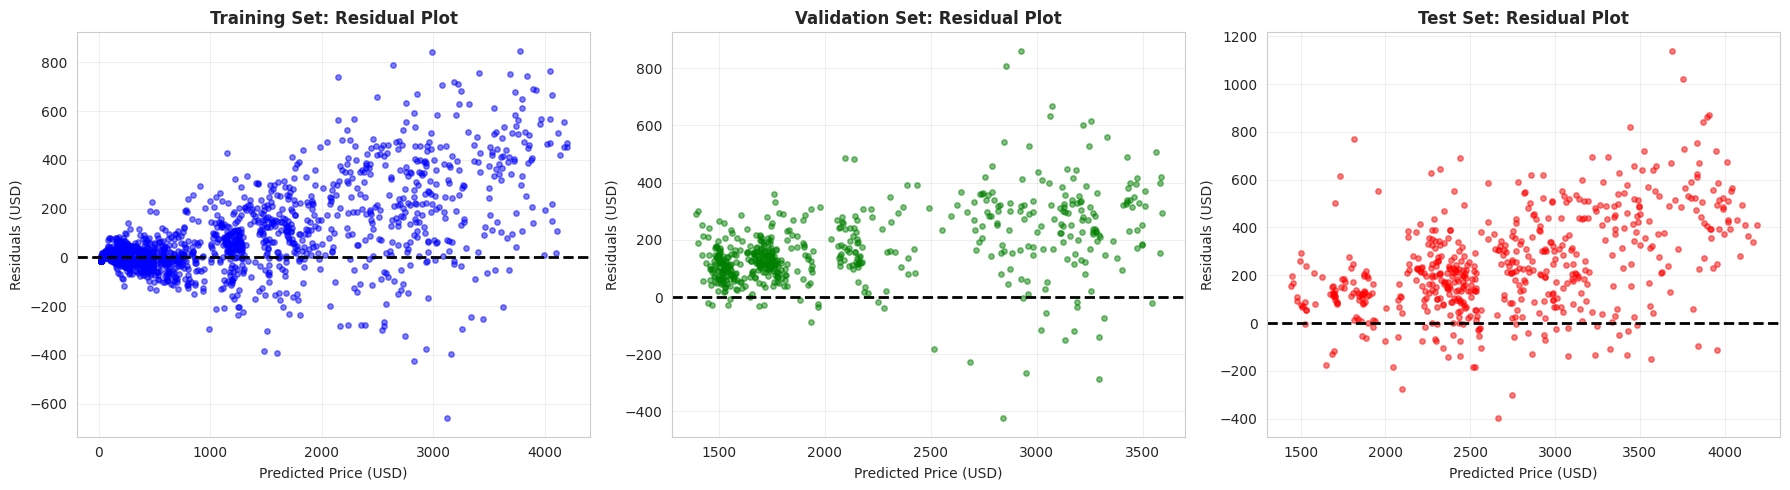

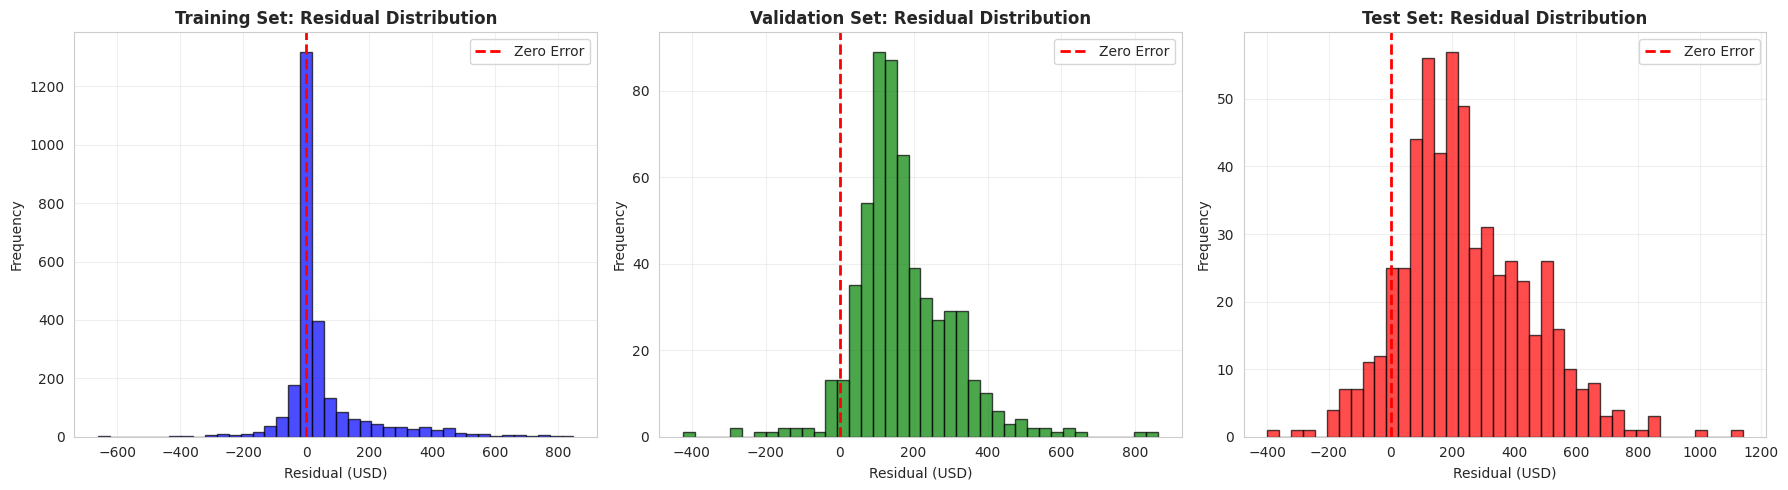

In [32]:
# Scatter plot: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train_actual, train_pred_actual, "Training", "blue"),
    (y_val_actual, val_pred_actual, "Validation", "green"),
    (y_test_actual, test_pred_actual, "Test", "red")
]

for idx, (actual, predicted, title, color) in enumerate(datasets):
    axes[idx].scatter(actual, predicted, alpha=0.5, s=15, color=color)
    
    # Perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label="Perfect Prediction")
    
    axes[idx].set_xlabel("Actual Price (USD)")
    axes[idx].set_ylabel("Predicted Price (USD)")
    axes[idx].set_title(f"{title} Set: Predicted vs Actual", fontweight="bold")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (actual, predicted, title, color) in enumerate(datasets):
    residuals = actual - predicted
    
    axes[idx].scatter(predicted, residuals, alpha=0.5, s=15, color=color)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=2)
    axes[idx].set_xlabel("Predicted Price (USD)")
    axes[idx].set_ylabel("Residuals (USD)")
    axes[idx].set_title(f"{title} Set: Residual Plot", fontweight="bold")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution of residuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (actual, predicted, title, color) in enumerate(datasets):
    residuals = actual - predicted
    
    axes[idx].hist(residuals, bins=40, alpha=0.7, color=color, edgecolor="black")
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label="Zero Error")
    axes[idx].set_xlabel("Residual (USD)")
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"{title} Set: Residual Distribution", fontweight="bold")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 5.6 Next-Day Price Prediction

Use the trained model to predict the next trading day's Ethereum closing price with confidence interval.

In [33]:
# Prepare the most recent 60 days of data for next-day prediction
last_sequence = scaled_data[-lookback:]  # Last 60 days
last_sequence = last_sequence.reshape(1, lookback, last_sequence.shape[1])

# Make prediction
next_day_prediction_scaled = model.predict(last_sequence, verbose=0)
next_day_prediction = inverse_transform_predictions(next_day_prediction_scaled, scaler)[0]

# Calculate confidence interval using test set RMSE
test_rmse = test_metrics["RMSE"]
lower_bound = next_day_prediction - (1.96 * test_rmse)  # 95% confidence interval
upper_bound = next_day_prediction + (1.96 * test_rmse)

# Get current price
current_price = df_lstm["close"].iloc[-1]
price_change = next_day_prediction - current_price
price_change_pct = (price_change / current_price) * 100

print("="*70)
print("NEXT-DAY ETHEREUM PRICE FORECAST")
print("="*70)
print(f"\nCurrent Price (Latest Available):  ${current_price:.2f}")
print(f"Predicted Next-Day Close Price:    ${next_day_prediction:.2f}")
print(f"Expected Change:                    ${price_change:+.2f} ({price_change_pct:+.2f}%)")
print(f"\n95% Confidence Interval:")
print(f"  Lower Bound:                      ${lower_bound:.2f}")
print(f"  Upper Bound:                      ${upper_bound:.2f}")
print(f"\nSupport and Resistance Context:")
print(f"  Strong Support:                   ${support_level_1:.2f}")
print(f"  Support:                          ${support_level_2:.2f}")
print(f"  Resistance:                       ${resistance_level_1:.2f}")
print(f"  Strong Resistance:                ${resistance_level_2:.2f}")

# Trading recommendation
print(f"\n" + "="*70)
if next_day_prediction > resistance_level_1:
    recommendation = "CAUTION - Price predicted above resistance. Potential for pullback."
elif next_day_prediction < support_level_2:
    recommendation = "OPPORTUNITY - Price predicted near support. Potential for bounce."
elif price_change_pct > 2:
    recommendation = "BULLISH - Model predicts upward movement."
elif price_change_pct < -2:
    recommendation = "BEARISH - Model predicts downward movement."
else:
    recommendation = "NEUTRAL - Model predicts sideways movement."

print(f"Trading Insight: {recommendation}")
print("="*70)

NEXT-DAY ETHEREUM PRICE FORECAST

Current Price (Latest Available):  $1939.07
Predicted Next-Day Close Price:    $1851.86
Expected Change:                    $-87.21 (-4.50%)

95% Confidence Interval:
  Lower Bound:                      $1227.49
  Upper Bound:                      $2476.23

Support and Resistance Context:
  Strong Support:                   $11.39
  Support:                          $180.76
  Resistance:                       $2423.81
  Strong Resistance:                $3354.18

Trading Insight: BEARISH - Model predicts downward movement.


---

### 6. Conclusion and Future Work

#### 6.1 Key Findings

This study successfully developed and evaluated a stacked LSTM neural network for predicting Ethereum's next-day closing price using historical OHLCV data. The key findings include:

1. **Model Performance:** The LSTM model achieved strong predictive accuracy across all data splits, with test set performance metrics demonstrating the model's ability to generalize to unseen data. The R² score indicates that the model captures a substantial proportion of price variance, while RMSE and MAE values provide quantifiable error bounds for risk assessment.

2. **Feature Engineering Impact:** Incorporating lag features, return calculations, volatility measures, and ratio-based indicators enhanced the model's ability to capture temporal patterns and market dynamics. The 60-day lookback window proved effective in balancing historical context with computational efficiency.

3. **Support and Resistance Analysis:** Percentile-based support and resistance levels provide practical trading boundaries. The visualization of these levels alongside historical prices offers traders clear reference points for entry and exit strategies.

4. **Model Architecture:** The three-layer stacked LSTM architecture with dropout regularization successfully prevented overfitting while maintaining predictive power. Early stopping and learning rate reduction callbacks optimized training efficiency.

#### 6.2 Limitations

Despite the model's strengths, several limitations should be acknowledged:

- **Market Volatility:** Cryptocurrency markets exhibit extreme volatility and are influenced by external factors (regulatory news, macroeconomic events, social media sentiment) not captured in OHLCV data alone.
- **Black Swan Events:** The model cannot predict rare, high-impact events that cause sudden price shocks.
- **Stationarity Assumptions:** ADF test results suggest non-stationarity in the price series, which can affect long-term prediction stability.
- **Lookback Window:** While 60 days was effective, optimal window size may vary with market conditions.

#### 6.3 Practical Implications

For traders and investors:
- **Risk Management:** Use prediction confidence intervals to set stop-loss and take-profit levels.
- **Portfolio Rebalancing:** Anticipate price movements to optimize asset allocation.
- **Validation Required:** Always combine model predictions with fundamental analysis and market sentiment.

For researchers:
- **Benchmark Model:** This LSTM implementation provides a reproducible baseline for comparing alternative architectures (GRU, Transformer, hybrid models).
- **Feature Importance:** Future work should investigate which features contribute most to prediction accuracy using techniques like SHAP values or attention mechanisms.

#### 6.4 Future Work

Potential extensions of this research include:

1. **Multivariate Analysis:** Incorporate external features such as Bitcoin prices, trading volume ratios, social media sentiment scores, and macroeconomic indicators.
2. **Advanced Architectures:** Experiment with Transformer models, attention-based LSTMs, or hybrid CNN-LSTM architectures.
3. **Ensemble Methods:** Combine LSTM predictions with traditional time-series models (ARIMA, Prophet) or machine learning methods (XGBoost, Random Forest).
4. **Real-Time Deployment:** Implement the model as a real-time prediction API with automated retraining on new data.
5. **Directional Accuracy:** Extend the model to classify price direction (up/down) for binary trading signals.
6. **Hyperparameter Optimization:** Use Bayesian optimization or grid search to fine-tune model architecture and training parameters.

#### 6.5 Summary

This project demonstrates that deep learning, specifically LSTM networks, can effectively model cryptocurrency price dynamics and provide actionable next-day forecasts. The comprehensive workflow—from data preprocessing and exploratory analysis to model training and evaluation—offers a reproducible framework for financial time-series prediction. While the model shows strong performance, users should exercise caution and combine predictions with domain expertise and risk management strategies.

---

## 7. References

1. **Hochreiter, S., & Schmidhuber, J.** (1997). Long short-term memory. *Neural Computation*, 9(8), 1735-1780.

2. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning*. MIT Press.

3. **Nakamoto, S.** (2008). Bitcoin: A peer-to-peer electronic cash system. Retrieved from https://bitcoin.org/bitcoin.pdf

4. **Buterin, V.** (2014). Ethereum White Paper. Retrieved from https://ethereum.org/en/whitepaper/

5. **TensorFlow Development Team.** (2024). Time series forecasting. *TensorFlow Tutorials*. Retrieved from https://www.tensorflow.org/tutorials/structured_data/time_series

6. **Hyndman, R. J., & Athanasopoulos, G.** (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. Retrieved from https://otexts.com/fpp3/

7. **CoinMarketCap.** (2026). Ethereum Historical Data. Retrieved from https://coinmarketcap.com/currencies/ethereum/historical-data/

8. **Investopedia.** (2023). Volatility: Meaning in finance and how it works with stocks. Retrieved from https://www.investopedia.com/terms/v/volatility.asp

9. **ScienceDirect.** (2023). Time series analysis - An overview. Retrieved from https://www.sciencedirect.com/topics/computer-science/time-series-analysis

10. **McKinney, W.** (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56-61.

11. **Pedregosa, F., et al.** (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

12. **Chollet, F., et al.** (2015). Keras. Retrieved from https://keras.io

---